# Portfolio Project: Online Retail Exploratory Data Analysis with Python

Overview
In this project, you will step into the shoes of an entry-level data analyst at an online retail company, helping interpret real-world data to help make a key business decision.

## Case Study
In this project, you will be working with transactional data from an online retail store. The dataset contains information about customer purchases, including product details, quantities, prices, and timestamps. Your task is to explore and analyze this dataset to gain insights into the store's sales trends, customer behavior, and popular products.

By conducting exploratory data analysis, you will identify patterns, outliers, and correlations in the data, allowing you to make data-driven decisions and recommendations to optimize the store's operations and improve customer satisfaction. Through visualizations and statistical analysis, you will uncover key trends, such as the busiest sales months, best-selling products, and the store's most valuable customers. Ultimately, this project aims to provide actionable insights that can drive business growth and efficiency.

Project Objectives
Describe data to answer key questions to uncover insights
Gain valuable insights that will help improve online retail performance
Provide analytic insights and data-driven recommendations

Dataset
The dataset you will be working with is the "Online Retail" dataset. It contains transactional data of an online retail store from 2010 to 2011. The dataset is available as a .xlsx file named Online Retail.xlsx. This data file is already included in the Coursera Jupyter Notebook environment, however if you are working off-platform it can also be downloaded here.

The dataset contains the following columns:

InvoiceNo: Invoice number of the transaction
StockCode: Unique code of the product
Description: Description of the product
Quantity: Quantity of the product in the transaction
InvoiceDate: Date and time of the transaction
UnitPrice: Unit price of the product
CustomerID: Unique identifier of the customer
Country: Country where the transaction occurred

Tasks
You may explore this dataset in any way you would like - however if you'd like some help getting started, here are a few ideas:

1- Load the dataset into a Pandas DataFrame and display the first few rows to get an overview of the data.
2- Perform data cleaning by handling missing values, if any, and removing any redundant or unnecessary columns.
3- Explore the basic statistics of the dataset, including measures of central tendency and dispersion.
4- Perform data visualization to gain insights into the dataset.
5- Generate appropriate plots, such as histograms, scatter plots, or bar plots, to visualize different aspects of the data.
6- Analyze the sales trends over time.
7- Identify the busiest months and days of the week in terms of sales.
8- Explore the top-selling products and countries with the highest sales.
9- Identify the store's most valuable customers.

# Importing the required libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set(color_codes=True)

# Task 1: Load the Data

In [2]:
df = pd.read_csv('online_retail.csv')
df.head(5)   # To display the top 5 rows

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape

(531282, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 531282 entries, 0 to 531281
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    531282 non-null  int64  
 1   StockCode    531282 non-null  str    
 2   Description  531282 non-null  str    
 3   Quantity     531282 non-null  int64  
 4   InvoiceDate  531282 non-null  str    
 5   UnitPrice    531282 non-null  float64
 6   CustomerID   531282 non-null  float64
 7   Country      531282 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 32.4 MB


# Task 2: Perform data cleaning

In [5]:
# Checking the types of data
df.dtypes

InvoiceNo        int64
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [6]:
# InvoiceDate is stored as text - convert it to an actual datetime so we can do time-based analysis
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.dtypes

InvoiceNo               int64
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [7]:
# Checking for duplicate rows
print("Rows before removing duplicates:", df.shape[0])
duplicate_rows_df = df[df.duplicated()]
print("Number of duplicate rows:", duplicate_rows_df.shape[0])

Rows before removing duplicates: 531282


Number of duplicate rows: 5231


In [8]:
# Dropping the duplicate rows
df = df.drop_duplicates()
print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 526051


In [9]:
# Checking for missing values.
# Note: in this dataset, CustomerID is encoded as 0 for guest/unidentified customers
# instead of being left blank, so a plain isnull() check would understate how many
# transactions have no known customer.
print("Rows with missing CustomerID (encoded as 0):", (df['CustomerID'] == 0).sum())
df.isnull().sum()

Rows with missing CustomerID (encoded as 0): 133319


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [10]:
# Removing rows that aren't real sales (free/zero-priced items, data entry errors)
print("Rows with UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())
df = df[df['UnitPrice'] > 0]
df.shape

Rows with UnitPrice <= 0: 1174


(524877, 8)

In [11]:
# Feature engineering: derive the fields we need for the sales/time analysis below
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,Wednesday,8


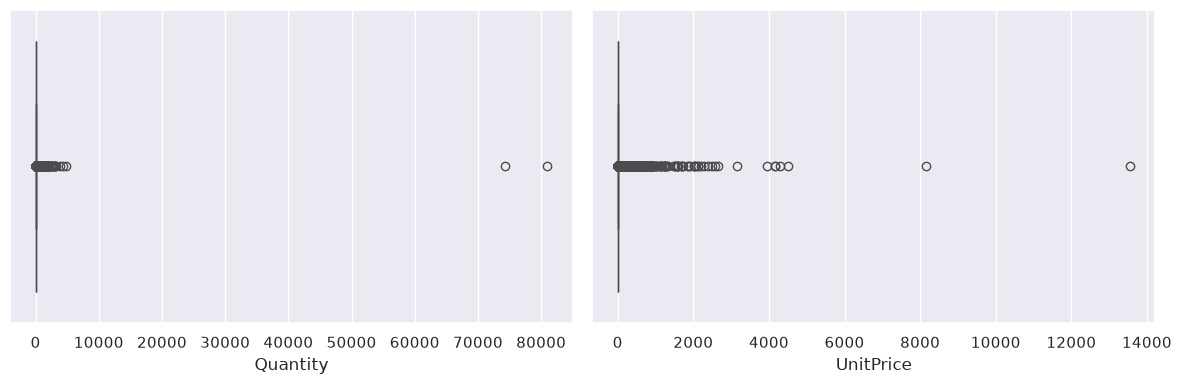

In [12]:
# Dealing with outliers
# Boxplots of Quantity and UnitPrice show a long tail of bulk wholesale orders
# and a handful of very high unit prices - both are legitimate but skew the stats below.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Quantity'], ax=axes[0])
sns.boxplot(x=df['UnitPrice'], ax=axes[1])
plt.tight_layout()
plt.show()

In [13]:
# IQR score technique - remove outliers in Quantity and UnitPrice
for col in ['Quantity', 'UnitPrice']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

df.shape

(460251, 12)

# Task 3: Explore the basic statistics of the dataset, including measures of central tendency and dispersion.

In [14]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Hour
count,460251.000000,460251.000000,460251,460251.000000,460251.000000,460251.000000,460251.000000
mean,560104.815155,6.182157,2011-07-05 22:11:46.295260,2.599133,11471.330285,11.729846,13.113084
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,0.000000,0.001000,6.000000
25%,548150.000000,1.000000,2011-03-29 12:55:00,1.250000,0.000000,3.300000,11.000000
50%,560834.000000,4.000000,2011-07-21 12:15:00,2.080000,14410.000000,8.250000,13.000000
75%,571940.000000,10.000000,2011-10-20 09:57:00,3.750000,16303.000000,15.900000,15.000000
max,581587.000000,26.000000,2011-12-09 12:50:00,8.330000,18287.000000,215.540000,20.000000
std,13414.981386,6.396944,NaN,1.929225,6804.444209,13.174559,2.428300


In [15]:
num_cols = ['Quantity', 'UnitPrice', 'TotalPrice']
print("Mean:\n", df[num_cols].mean())
print("\nMedian:\n", df[num_cols].median())
print("\nMode:\n", df[num_cols].mode().iloc[0])

Mean:
 Quantity       6.182157
UnitPrice      2.599133
TotalPrice    11.729846
dtype: float64

Median:
 Quantity      4.00
UnitPrice     2.08
TotalPrice    8.25
dtype: float64

Mode:
 Quantity       1.00
UnitPrice      1.25
TotalPrice    15.00
Name: 0, dtype: float64


In [16]:
print("Variance:\n", df[num_cols].var())
print("\nStandard Deviation:\n", df[num_cols].std())

Variance:
 Quantity       40.920891
UnitPrice       3.721909
TotalPrice    173.568992
dtype: float64

Standard Deviation:
 Quantity       6.396944
UnitPrice      1.929225
TotalPrice    13.174559
dtype: float64


In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 460251 entries, 0 to 531281
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     460251 non-null  int64         
 1   StockCode     460251 non-null  str           
 2   Description   460251 non-null  str           
 3   Quantity      460251 non-null  int64         
 4   InvoiceDate   460251 non-null  datetime64[us]
 5   UnitPrice     460251 non-null  float64       
 6   CustomerID    460251 non-null  float64       
 7   Country       460251 non-null  str           
 8   TotalPrice    460251 non-null  float64       
 9   InvoiceMonth  460251 non-null  str           
 10  DayOfWeek     460251 non-null  str           
 11  Hour          460251 non-null  int32         
dtypes: datetime64[us](1), float64(3), int32(1), int64(2), str(5)
memory usage: 43.9 MB


# Task 4: Analyze the Data

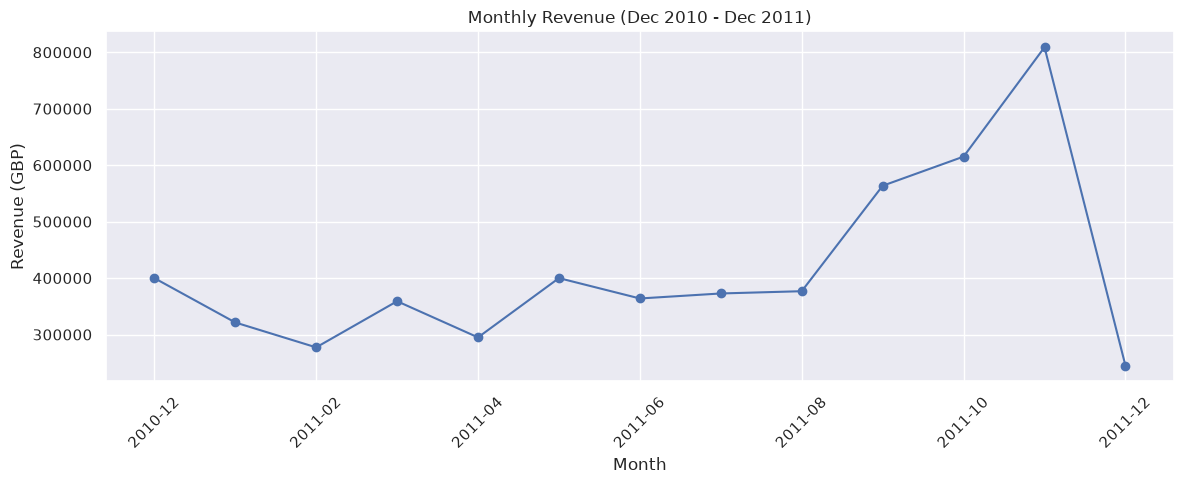

In [18]:
# Sales trends over time
monthly_sales = df.groupby('InvoiceMonth')['TotalPrice'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Revenue (Dec 2010 - Dec 2011)')
plt.ylabel('Revenue (GBP)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

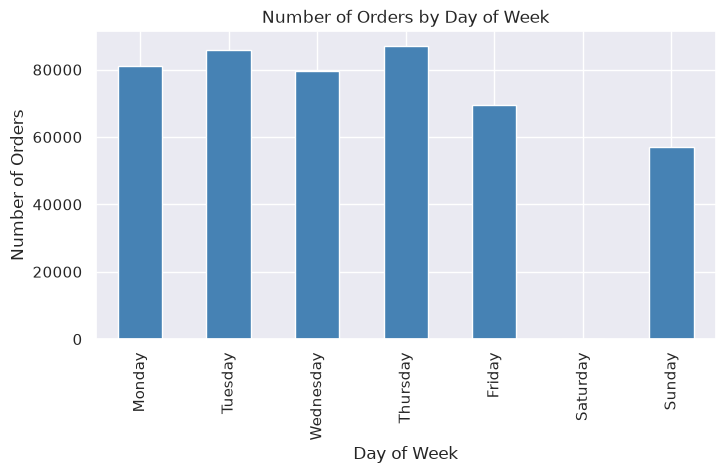

In [19]:
# Busiest days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayOfWeek'].value_counts().reindex(day_order).plot(kind='bar', figsize=(8, 4), color='steelblue')
plt.title('Number of Orders by Day of Week')
plt.ylabel('Number of Orders')
plt.xlabel('Day of Week')
plt.show()

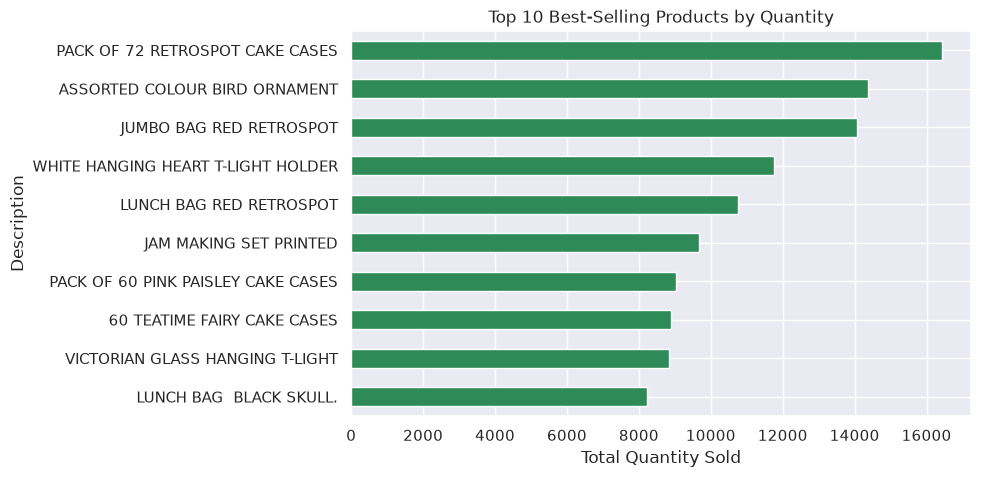

In [20]:
# Top-selling products by quantity
df.groupby('Description')['Quantity'].sum().nlargest(10).plot(kind='barh', figsize=(8, 5), color='seagreen')
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.gca().invert_yaxis()
plt.show()

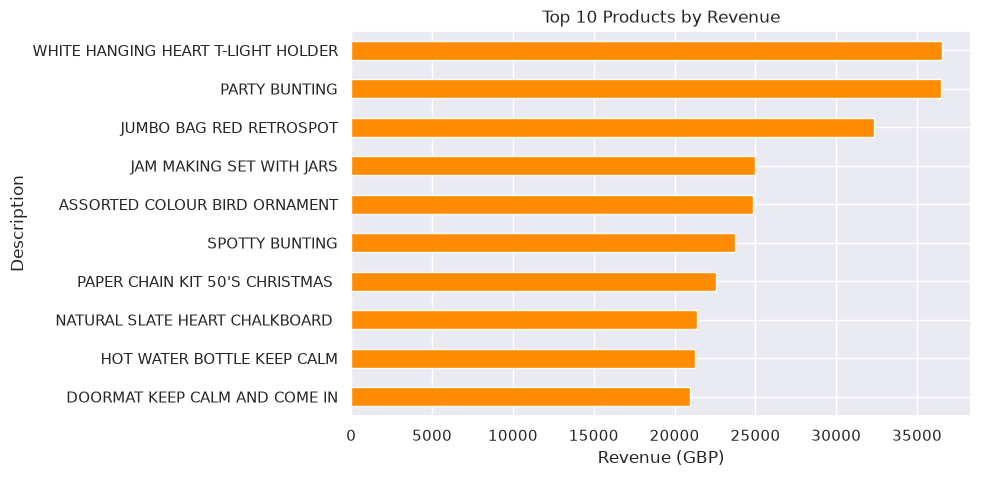

In [21]:
# Top products by revenue
df.groupby('Description')['TotalPrice'].sum().nlargest(10).plot(kind='barh', figsize=(8, 5), color='darkorange')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (GBP)')
plt.gca().invert_yaxis()
plt.show()

In [22]:
# Revenue by country
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United Kingdom    4722105.834
Germany            144951.980
France             128614.750
EIRE               124190.290
Switzerland         32906.470
Spain               31310.660
Belgium             28444.360
Portugal            21405.680
Norway              19363.860
Netherlands         18523.700
Name: TotalPrice, dtype: float64

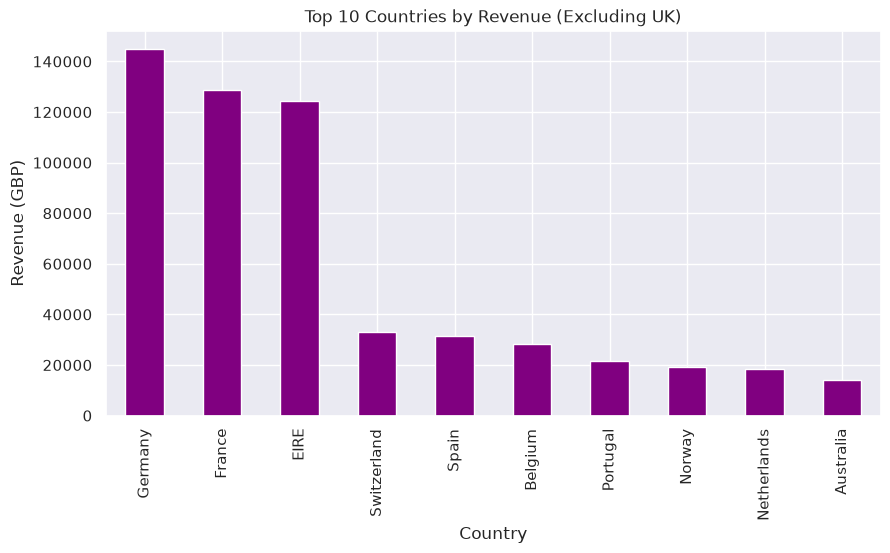

In [23]:
# The UK dominates revenue as expected for a UK-based retailer, so we look at
# the next-highest countries separately to see where the international demand is.
country_sales.drop('United Kingdom').nlargest(10).plot(kind='bar', figsize=(10, 5), color='purple')
plt.title('Top 10 Countries by Revenue (Excluding UK)')
plt.ylabel('Revenue (GBP)')
plt.show()

In [24]:
# Most valuable customers (excluding CustomerID == 0, which marks guest/unknown customers)
customer_sales = df[df['CustomerID'] != 0].groupby('CustomerID')['TotalPrice'].sum().nlargest(10)
customer_sales

CustomerID
14911.0    91209.24
13089.0    38565.78
14096.0    38556.58
17841.0    33847.34
14298.0    25395.00
12748.0    21476.30
14156.0    19713.86
15311.0    19012.76
13081.0    18068.63
14088.0    17460.31
Name: TotalPrice, dtype: float64

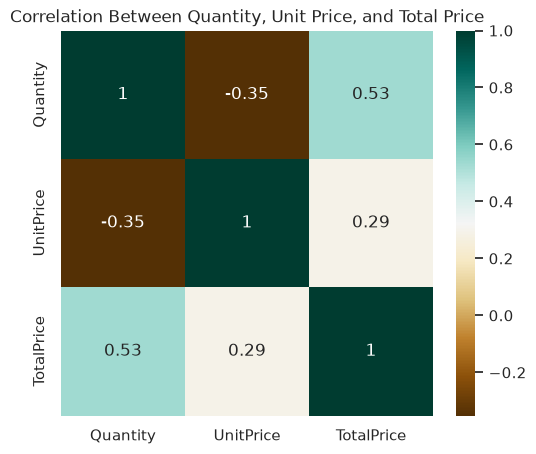

In [25]:
# Heat map - correlation between quantity, unit price and revenue
plt.figure(figsize=(6, 5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='BrBG')
plt.title('Correlation Between Quantity, Unit Price, and Total Price')
plt.show()

What I learned throughout the process is how important it is to:

Inspect the dataset carefully before analysis, especially to understand column types, encodings for missing data (e.g. CustomerID stored as 0), and duplicate records.

Clean and preprocess the data by converting dates, removing non-sales rows, and dropping duplicates before trusting any aggregate statistic.

Identify and handle outliers using statistical techniques like the Interquartile Range (IQR), since a small number of bulk wholesale orders can otherwise dominate the averages.

Use visualizations such as boxplots, line charts, bar charts, and heatmaps to surface patterns - like seasonality and top products - that are not obvious from raw numbers alone.

Aggregate at the right grain (by month, by day of week, by product, by country, by customer) depending on the business question being asked.

Were the results what I expected?

It was expected that revenue would build toward the end of the year given the run-up to Christmas, and the data confirms this: revenue climbs steadily from September and peaks in November 2011, before dropping off sharply in the (partial) December 2011 data.

The store does not appear to take orders on Saturdays, which was a bit of a surprise until you consider this is a business-facing wholesale operation rather than a typical consumer storefront - most of its customers are other businesses re-selling the goods.

The United Kingdom accounts for the overwhelming majority of revenue, which is expected for a UK-registered retailer, with Germany, France, and Ireland (EIRE) as the next-largest markets by a wide margin.

Quantity and TotalPrice are moderately positively correlated, while UnitPrice is only weakly correlated with TotalPrice - revenue per order is driven more by how many units are bought than by the price of any single item.

Key Findings and Takeaways
Here are the main insights from the analysis:

1. Sales are strongly seasonal
Revenue rises through the autumn and peaks in November, consistent with retailers stocking up ahead of the holiday season. This store would benefit from planning inventory and staffing around that peak.

2. A small set of products drives a large share of demand
Items like the "WHITE HANGING HEART T-LIGHT HOLDER", "PARTY BUNTING", and "JUMBO BAG RED RETROSPOT" are consistently among the top sellers by both quantity and revenue, making them strong candidates for promotional focus and stock prioritization.

3. The business is concentrated in the UK but has a meaningful export tail
Germany, France, and EIRE are the next-largest markets after the UK, suggesting a modest but real opportunity to grow international sales further.

4. Order volume matters more than price for revenue
Because Quantity correlates with TotalPrice more strongly than UnitPrice does, encouraging larger basket sizes (bundles, bulk discounts) is likely to move revenue more than price changes alone.

5. A meaningful share of transactions have no identified customer
Guest/unidentified purchases (CustomerID encoded as 0) make up a notable portion of orders; getting more customers to register would enable better personalization and loyalty analysis in the future.